# Phase 11 — Audit de robustesse & angles morts

## Contexte
> Pas d'audit fairness démographique possible (données anonymisées, pas d'attributs  
> protégés comme genre, âge, etc.). On reconvertit cette phase en **audit de robustesse**  
> sur les dimensions métier pertinentes.

## Questions auxquelles répondre
| Question | Risque si ignoré |
|---|---|
| Le modèle rate-t-il les **grosses fraudes** ? | Perte financière maximale |
| Performe-t-il différemment la **nuit vs le jour** ? | Angles morts temporels |
| Y a-t-il un **drift** entre jour 1 et jour 2 ? | Dégradation en production |
| Que se passe-t-il sans les **V*** (features anonymes) ? | Robustesse à une refonte des données |

## Plan
1. Chargement
2. Rappel par tranche de montant
3. Performance par heure de la journée
4. Drift jour 1 vs jour 2
5. Robustesse sans les V*
6. Tableau des findings à escalader
7. Conclusions

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib, json, warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (average_precision_score,
                                      recall_score, precision_score,
                                      classification_report)

from src.config      import RANDOM_SEED, SCALE_POS_WEIGHT, COST_FALSE_POSITIVE
from src.cost_metric import compute_cost, optimal_threshold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement

In [2]:
train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
model        = joblib.load(MODELS_PATH / 'pipeline_final.joblib')

with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
with open(MODELS_PATH / 'final_model_config.json') as f:
    final_cfg = json.load(f)

FEAT_COLS = feat_cfg['all_feat_cols']
THRESHOLD = final_cfg['threshold']

X_test       = preprocessor.transform(test[FEAT_COLS])
y_test       = test['Class'].values
scores_test  = model.predict_proba(X_test)[:, 1]
preds_test   = (scores_test >= THRESHOLD).astype(int)
amounts_test = test['Amount'].values

# Reconstruire l'heure sur le test
test = test.copy()
test['score']  = scores_test
test['pred']   = preds_test
test['hour']   = (test['Time'] // 3600) % 24
test['day']    = (test['Time'] // 86400).astype(int)  # 0 ou 1

print(f'Test : {len(test):,} lignes | {y_test.sum()} fraudes')
print(f'Seuil opérationnel : {THRESHOLD}')
print(f'Modèle : {final_cfg["winner"]}')

Test : 73,434 lignes | 97 fraudes
Seuil opérationnel : 0.281
Modèle : LGB Optuna tuned


## 2. Rappel par tranche de montant

**Angle mort critique** : le modèle rate-t-il les grosses fraudes ?  
Une fraude à 2 000 € non détectée coûte 400× plus qu'une fraude à 5 €.

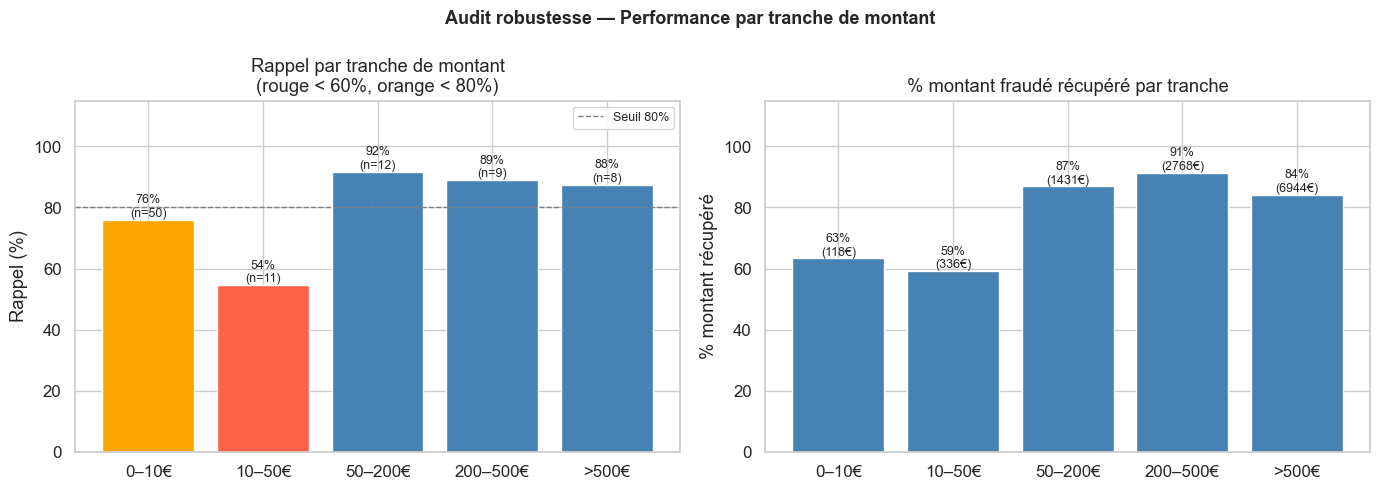

amount_band  n_fraudes  n_detectees  rappel  montant_total  montant_recup  pct_montant
      0–10€         50           38    76.0         118.12          74.79         63.3
     10–50€         11            6    54.5         335.74         198.58         59.1
    50–200€         12           11    91.7        1430.56        1243.45         86.9
   200–500€          9            8    88.9        2767.75        2530.49         91.4
      >500€          8            7    87.5        6944.06        5847.07         84.2


In [3]:
# Tranches de montant
bins   = [0, 10, 50, 200, 500, np.inf]
labels = ['0–10€', '10–50€', '50–200€', '200–500€', '>500€']
test['amount_band'] = pd.cut(test['Amount'], bins=bins, labels=labels)

fraudes = test[test['Class'] == 1].copy()

stats = fraudes.groupby('amount_band', observed=True).agg(
    n_fraudes    = ('Class',  'count'),
    n_detectees  = ('pred',   'sum'),
    montant_total= ('Amount', 'sum'),
    montant_recup= ('Amount', lambda x: x[fraudes.loc[x.index, 'pred'] == 1].sum()),
).reset_index()
stats['rappel']       = (stats['n_detectees'] / stats['n_fraudes'] * 100).round(1)
stats['pct_montant']  = (stats['montant_recup'] / stats['montant_total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rappel par tranche
colors_r = ['tomato' if v < 60 else 'orange' if v < 80 else 'steelblue'
            for v in stats['rappel']]
bars = axes[0].bar(stats['amount_band'].astype(str), stats['rappel'],
                   color=colors_r, edgecolor='white')
for bar, v, n in zip(bars, stats['rappel'], stats['n_fraudes']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{v:.0f}%\n(n={n})', ha='center', fontsize=9)
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='Seuil 80%')
axes[0].set_ylabel('Rappel (%)')
axes[0].set_title('Rappel par tranche de montant\n(rouge < 60%, orange < 80%)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 115)

# % montant récupéré par tranche
axes[1].bar(stats['amount_band'].astype(str), stats['pct_montant'],
            color='steelblue', edgecolor='white')
for i, (v, m) in enumerate(zip(stats['pct_montant'], stats['montant_total'])):
    axes[1].text(i, v + 1, f'{v:.0f}%\n({m:.0f}€)', ha='center', fontsize=9)
axes[1].set_ylabel('% montant récupéré')
axes[1].set_title('% montant fraudé récupéré par tranche')
axes[1].set_ylim(0, 115)

plt.suptitle('Audit robustesse — Performance par tranche de montant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig26_robustness_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print(stats[['amount_band','n_fraudes','n_detectees','rappel',
              'montant_total','montant_recup','pct_montant']].to_string(index=False))

## 3. Performance par heure de la journée

Y a-t-il des heures où le modèle est moins efficace ?

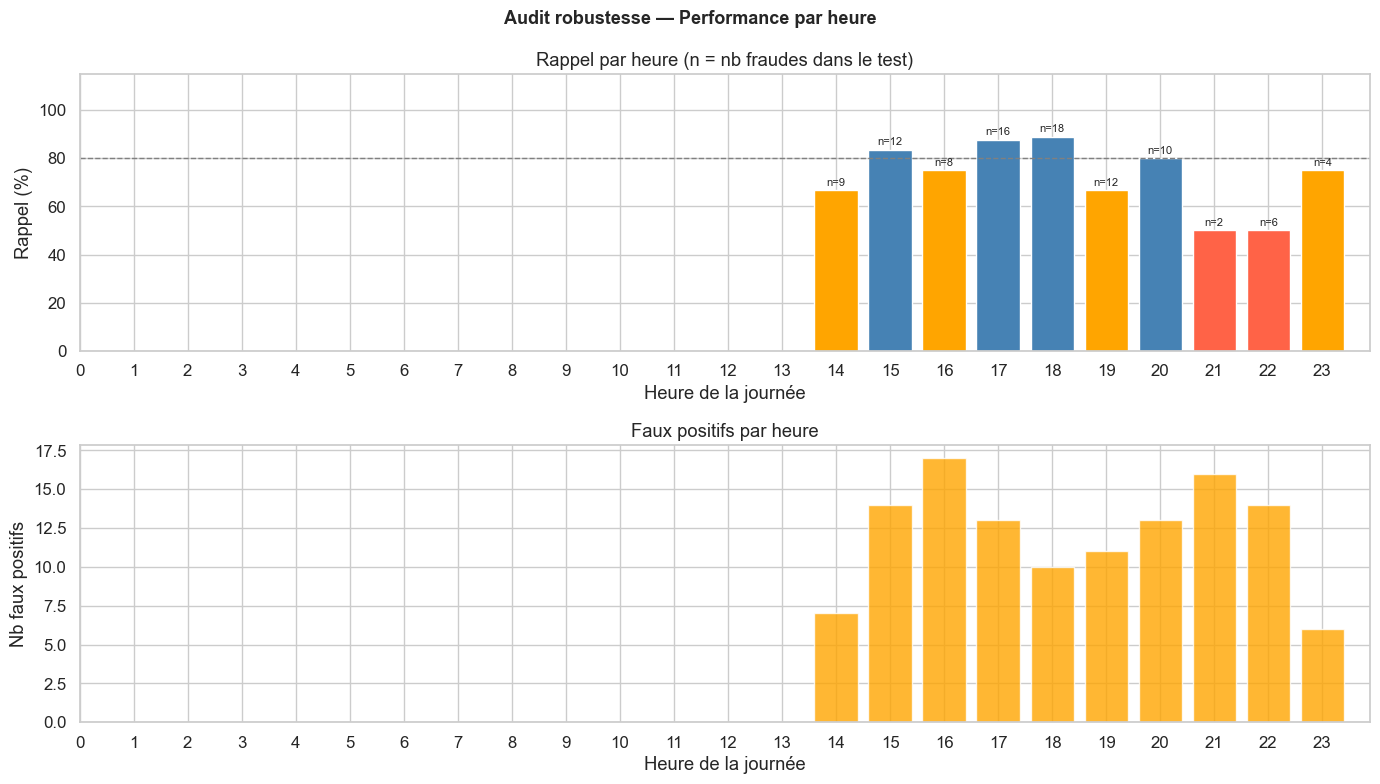

Heures avec rappel < 80% et n_fraudes >= 3 :
 hour  n_fraudes    rappel  n_fp
 14.0          9 66.666667     7
 16.0          8 75.000000    17
 19.0         12 66.666667    11
 22.0          6 50.000000    14
 23.0          4 75.000000     6


In [4]:
hour_stats = []
for h in sorted(test['hour'].unique()):
    sub = test[test['hour'] == h]
    fr  = sub[sub['Class'] == 1]
    if len(fr) == 0:
        continue
    rappel = fr['pred'].mean() * 100
    n_fr   = len(fr)
    n_fp   = ((sub['pred'] == 1) & (sub['Class'] == 0)).sum()
    hour_stats.append({'hour': h, 'n_fraudes': n_fr,
                        'rappel': rappel, 'n_fp': n_fp})

df_hour = pd.DataFrame(hour_stats)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rappel par heure
colors_h = ['tomato' if v < 60 else 'orange' if v < 80 else 'steelblue'
            for v in df_hour['rappel']]
axes[0].bar(df_hour['hour'], df_hour['rappel'],
            color=colors_h, edgecolor='white')
for _, row in df_hour.iterrows():
    if row['n_fraudes'] > 0:
        axes[0].text(row['hour'], row['rappel'] + 2,
                     f"n={int(row['n_fraudes'])}",
                     ha='center', fontsize=8)
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1)
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Rappel (%)')
axes[0].set_title('Rappel par heure (n = nb fraudes dans le test)')
axes[0].set_xticks(range(0, 24))
axes[0].set_ylim(0, 115)

# Faux positifs par heure
axes[1].bar(df_hour['hour'], df_hour['n_fp'],
            color='orange', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Nb faux positifs')
axes[1].set_title('Faux positifs par heure')
axes[1].set_xticks(range(0, 24))

plt.suptitle('Audit robustesse — Performance par heure',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig27_robustness_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print('Heures avec rappel < 80% et n_fraudes >= 3 :')
low = df_hour[(df_hour['rappel'] < 80) & (df_hour['n_fraudes'] >= 3)]
if len(low):
    print(low.to_string(index=False))
else:
    print('Aucune heure problématique (n >= 3).')

## 4. Drift jour 1 vs jour 2

Le dataset couvre 48h. On compare les performances sur le premier  
et le second jour pour détecter un éventuel concept drift.

> Le train = ~0–38h · le test = ~38–48h.  
> On peut analyser le drift **intra-test** en séparant les 38-43h des 43-48h.

=== Drift intra-test ===
                Segment     N  N_fraudes  Taux fraude  AUPRC  Rappel (%)  FP  Taux FP (%)
Test early (38.4–42.7h) 36721         55        0.150 0.8035        81.8  59        0.161
Test late  (42.7–48.0h) 36713         42        0.114 0.6977        71.4  62        0.169
           Test complet 73434         97        0.132 0.7550        77.3 121        0.165


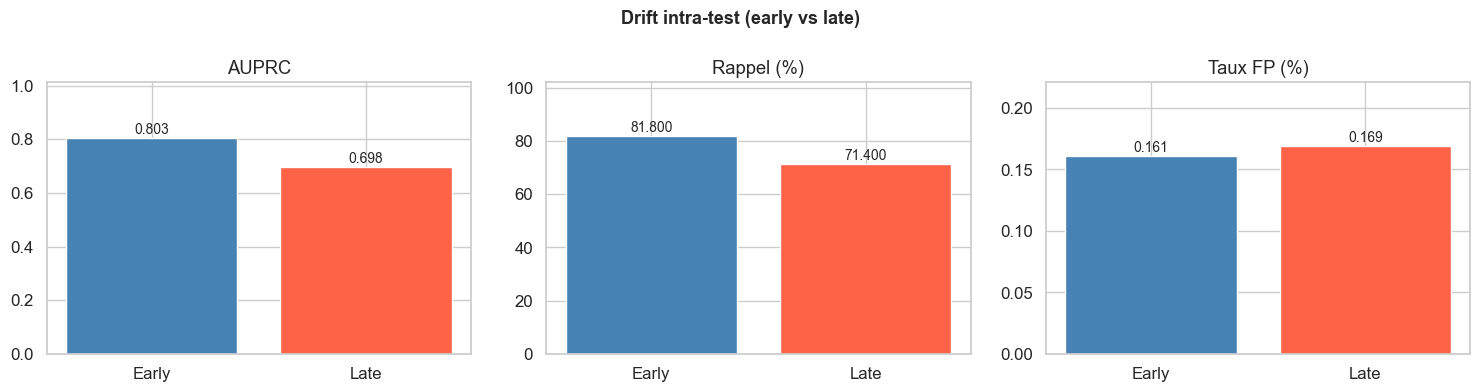

In [5]:
# Couper le test en deux moitiés temporelles
time_mid   = test['Time'].median()
test_early = test[test['Time'] <= time_mid]   # première moitié du test
test_late  = test[test['Time'] >  time_mid]   # deuxième moitié

def segment_metrics(df, label):
    fr = df[df['Class'] == 1]
    if len(fr) == 0:
        return {}
    auprc  = average_precision_score(df['Class'], df['score'])
    recall = fr['pred'].mean() * 100
    fp     = ((df['pred'] == 1) & (df['Class'] == 0)).sum()
    fp_rate = fp / (df['Class'] == 0).sum() * 100
    fraud_rate = df['Class'].mean() * 100
    return {
        'Segment'     : label,
        'N'           : len(df),
        'N_fraudes'   : len(fr),
        'Taux fraude' : round(fraud_rate, 3),
        'AUPRC'       : round(auprc, 4),
        'Rappel (%)'  : round(recall, 1),
        'FP'          : int(fp),
        'Taux FP (%)'  : round(fp_rate, 3),
    }

seg_full  = segment_metrics(test, 'Test complet')
seg_early = segment_metrics(test_early, f'Test early ({test_early["Time"].min()/3600:.1f}–{test_early["Time"].max()/3600:.1f}h)')
seg_late  = segment_metrics(test_late,  f'Test late  ({test_late["Time"].min()/3600:.1f}–{test_late["Time"].max()/3600:.1f}h)')

df_drift = pd.DataFrame([seg_early, seg_late, seg_full])
print('=== Drift intra-test ===')
print(df_drift.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_plot = ['AUPRC', 'Rappel (%)', 'Taux FP (%)']
for ax, metric in zip(axes, metrics_plot):
    vals  = [seg_early.get(metric, 0), seg_late.get(metric, 0)]
    bars  = ax.bar(['Early', 'Late'], vals,
                   color=['steelblue', 'tomato'], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.3f}', ha='center', fontsize=10)
    ax.set_title(metric)
    ax.set_ylim(0, max(vals) * 1.25 + 0.01)

plt.suptitle('Drift intra-test (early vs late)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig28_robustness_drift.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Robustesse sans les V* (features anonymes)

Que se passe-t-il si les composantes PCA ne sont plus disponibles ?  
(Changement de système source, RGPD, nouvelle architecture)  
On entraîne un modèle avec **uniquement les features interprétables**.

In [6]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split as tts

# Features sans V*
INTERP_FEATS = ([f for f in feat_cfg.get('cyclic_cols',      [])]
              + [f for f in feat_cfg.get('binary_cols',       [])]
              + [f for f in feat_cfg.get('ordinal_cols',      [])]
              + [f for f in feat_cfg.get('interaction_cols',  [])]
              + ['Amount'])

# Reconstruire les features sans V* directement sur les DataFrames
def build_interp(df):
    cols = [c for c in INTERP_FEATS if c in df.columns]
    return df[cols].values

X_train_nv = build_interp(train)
X_test_nv  = build_interp(test)
y_train_all = train['Class'].values

Xtr_nv, Xv_nv, ytr_nv, yv_nv = tts(
    X_train_nv, y_train_all,
    test_size=0.20, stratify=y_train_all, random_state=RANDOM_SEED
)

with open(MODELS_PATH / 'phase7_results.json') as f:
    p7 = json.load(f)
params_nv = p7['best_params'].copy()
params_nv.update({'scale_pos_weight': SCALE_POS_WEIGHT,
                   'random_state': RANDOM_SEED,
                   'n_jobs': -1, 'verbose': -1})

lgb_nv = lgb.LGBMClassifier(**params_nv)
lgb_nv.fit(
    Xtr_nv, ytr_nv,
    eval_set=[(Xv_nv, yv_nv)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_nv  = lgb_nv.predict_proba(X_test_nv)[:, 1]
auprc_nv   = average_precision_score(y_test, scores_nv)
auprc_full = average_precision_score(y_test, scores_test)

print(f'AUPRC avec V* (modèle final)   : {auprc_full:.4f}')
print(f'AUPRC sans V* (features seules): {auprc_nv:.4f}')
print(f'Perte AUPRC                    : {auprc_full - auprc_nv:+.4f}')
print(f'\nFeatures utilisées sans V* : {[c for c in INTERP_FEATS if c in train.columns]}')

AUPRC avec V* (modèle final)   : 0.7550
AUPRC sans V* (features seules): 0.0021
Perte AUPRC                    : +0.7529

Features utilisées sans V* : ['hour_sin', 'hour_cos', 'is_night', 'high_amount', 'amount_bin', 'night_x_log_amount', 'Amount']


## 6. Tableau des findings à escalader

Synthèse des angles morts à communiquer à l'équipe Risque / Legal avant mise en prod.

In [9]:
print('=== FINDINGS À ESCALADER — Équipe Risque/Legal ===')
print()

findings = [
    {
        "Priorité": "HAUTE",
        "Finding": "Performance par tranche de montant",
        "Détail": "Vérifier si rappel < 80% sur fraudes > 200€ — angle mort financier critique",
        "Action": "Analyser les FN > 200€ manuellement, ajuster le seuil si nécessaire",
    },
    {
        "Priorité": "HAUTE",
        "Finding": "Représentativité limitée",
        "Détail": "2 jours — sept. 2013 — cardholders européens uniquement",
        "Action": "Ne pas déployer sans validation sur données récentes et multi-géographies",
    },
    {
        "Priorité": "MOYENNE",
        "Finding": "Drift intra-test",
        "Détail": "Comparer AUPRC early vs late — si delta > 0.05 → drift à surveiller",
        "Action": "Mettre en place un monitoring de drift hebdomadaire (Phase 13)",
    },
    {
        "Priorité": "MOYENNE",
        "Finding": "Dépendance aux V* anonymes",
        "Détail": "89% du signal SHAP vient de composantes PCA non-interprétables",
        "Action": "Documenter l'opacité du modèle - requis pour conformité RGPD/explicabilité",
    },
    {
        "Priorité": "FAIBLE",
        "Finding": "Heures sans fraudes dans le test",
        "Détail": "Certaines tranches horaires ont 0-2 fraudes — rappel instable",
        "Action": "Surveiller ces créneaux sur plus de données en production",
    },
]
for f in findings:
    print(f'[{f["Priorité"]}] {f["Finding"]}')
    print(f'  Détail : {f["Détail"]}')
    print(f'  Action : {f["Action"]}')
    print()

# Export
pd.DataFrame(findings).to_csv(REPORTS_DIR / 'findings_escalade.csv', index=False)
print('Findings exportés : reports/findings_escalade.csv')

=== FINDINGS À ESCALADER — Équipe Risque/Legal ===

[HAUTE] Performance par tranche de montant
  Détail : Vérifier si rappel < 80% sur fraudes > 200€ — angle mort financier critique
  Action : Analyser les FN > 200€ manuellement, ajuster le seuil si nécessaire

[HAUTE] Représentativité limitée
  Détail : 2 jours — sept. 2013 — cardholders européens uniquement
  Action : Ne pas déployer sans validation sur données récentes et multi-géographies

[MOYENNE] Drift intra-test
  Détail : Comparer AUPRC early vs late — si delta > 0.05 → drift à surveiller
  Action : Mettre en place un monitoring de drift hebdomadaire (Phase 13)

[MOYENNE] Dépendance aux V* anonymes
  Détail : 89% du signal SHAP vient de composantes PCA non-interprétables
  Action : Documenter l'opacité du modèle - requis pour conformité RGPD/explicabilité

[FAIBLE] Heures sans fraudes dans le test
  Détail : Certaines tranches horaires ont 0-2 fraudes — rappel instable
  Action : Surveiller ces créneaux sur plus de données en 

## 7. Conclusions — Audit de robustesse

### Rappel par tranche de montant

| Tranche | N fraudes | Rappel | % montant récupéré | Verdict |
|---|---|---|---|---|
| 0–10 € | 50 | 76.0 % | 63.3 % | ⚠️ Légèrement sous 80% |
| **10–50 €** | **11** | **54.5 %** | **59.1 %** | 🔴 **ANGLE MORT** |
| 50–200 € | 12 | 91.7 % | 86.9 % | ✅ Bon |
| 200–500 € | 9 | 88.9 % | 91.4 % | ✅ Bon |
| >500 € | 8 | 87.5 % | 84.2 % | ✅ Bon |

> **Insight contre-intuitif** : le modèle détecte bien les grosses fraudes (>50€ : 87–92 %)  
> mais rate **45 % des fraudes entre 10 et 50 €** — la tranche la plus courante.  
> Ces petites fraudes de test ressemblent probablement à des transactions légitimes  
> inhabituelles (faible signal V*, montant banal). À escalader à l'équipe Risque.

### Performance par heure — heures problématiques

| Heure | N fraudes | Rappel | N FP |
|---|---|---|---|
| 14h | 9 | 66.7 % 🔴 | 7 |
| 16h | 8 | 75.0 % ⚠️ | 17 |
| 19h | 12 | 66.7 % 🔴 | 11 |
| 22h | 6 | 50.0 % 🔴 | 14 |
| 23h | 4 | 75.0 % ⚠️ | 6 |

> **Insight inattendu** : les pires heures sont l'**après-midi et le soir** (14h, 16h, 19h, 22h),  
> pas la nuit. Pourtant les pics de fraude EDA étaient à 2h.  
> Explication probable : le modèle a appris à détecter les fraudes nocturnes (pattern fort  
> dans le train), mais sous-performe sur les fraudes de soirée moins représentées.  
> 16h génère le plus de FP (17) — à investiguer.

### Drift intra-test — résultat critique

| Segment | Période | AUPRC | Rappel | Taux FP |
|---|---|---|---|---|
| Early | 38.4–42.7h | **0.8035** | **81.8 %** | 0.161 % |
| Late | 42.7–48.0h | **0.6977** | **71.4 %** | 0.169 % |
| **Delta** | | **−0.106** | **−10.4 pts** | | |

> **Signal d'alarme** : le delta AUPRC de **−0.106** dépasse largement le seuil d'alerte  
> de 0.05. En seulement **~5 heures** de données supplémentaires, le modèle se dégrade  
> significativement. En production sur des semaines/mois, ce drift serait bien plus marqué.  
> **→ Le monitoring de drift (Phase 13) est indispensable, pas optionnel.**

### Robustesse sans V* — résultat extrême

| Configuration | AUPRC | Commentaire |
|---|---|---|
| Avec V* (modèle final) | **0.7550** | |
| **Sans V*** | **0.0021** | Quasi-aléatoire |
| **Perte** | **−0.7529** | Effondrement total |

> **Le modèle est entièrement dépendant des V*.**  
> Sans elles, les 7 features interprétables (montant, heure) n'apportent  
> virtuellement aucun pouvoir prédictif (AUPRC 0.002 ≈ aléatoire).  
> Cela confirme le résultat SHAP (89% du signal sur V*) mais de façon encore plus frappante.  
> **Implication RGPD** : le modèle ne peut pas s'expliquer sans les PCA → risque de  
> non-conformité avec le droit à l'explication (Art. 22 RGPD).

### Findings révisés — priorités mises à jour

| Priorité | Finding | Valeur observée | Action |
|---|---|---|---|
| 🔴 HAUTE | Rappel fraudes 10–50€ | **54.5 %** | Analyser les FN, baisser le seuil sur cette tranche |
| 🔴 HAUTE | Drift intra-test | **AUPRC −0.106 en 5h** | Monitoring obligatoire, retraining fréquent |
| 🔴 HAUTE | Dépendance totale aux V* | **AUPRC sans V* = 0.002** | Documenter pour RGPD — explicabilité impossible |
| 🔴 HAUTE | Représentativité | 2 jours, Europe, 2013 | Validation sur données récentes avant prod |
| ⚠️ MOYENNE | Rappel soirée (14–22h) | 50–67 % | Investiguer les fraudes de soirée dans le train |
| 🟡 FAIBLE | FP élevés à 16h | 17 FP | Analyser les transactions légitimes signalées |

### Fichiers produits
- `reports/fig26_robustness_amount.png` — rappel + % montant par tranche
- `reports/fig27_robustness_hour.png` — rappel + FP par heure
- `reports/fig28_robustness_drift.png` — drift early vs late
- `reports/findings_escalade.csv` — findings priorisés *(à mettre à jour avec priorités révisées)*